### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings 

warnings.filterwarnings("ignore")

### Load Dataset

In [2]:
fertilizer = pd.read_csv("../Data Set/fertilizer_recommendation_dataset.csv")

In [67]:
fertilizer.head()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."


In [68]:
fertilizer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3100 non-null   float64
 1   Moisture     3100 non-null   float64
 2   Rainfall     3100 non-null   float64
 3   PH           3100 non-null   float64
 4   Nitrogen     3100 non-null   float64
 5   Phosphorous  3100 non-null   float64
 6   Potassium    3100 non-null   float64
 7   Carbon       3100 non-null   float64
 8   Soil         3100 non-null   object 
 9   Crop         3100 non-null   object 
 10  Fertilizer   3100 non-null   object 
 11  Remark       3100 non-null   object 
dtypes: float64(8), object(4)
memory usage: 290.8+ KB


In [69]:
fertilizer.describe()
# fertilizer.describe(include=object)

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon
count,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000
mean,27.271096,0.600763,111.024949,6.379775,61.278480,69.582850,69.721167,1.474325
std,9.114450,0.144947,77.151880,0.957103,10.186410,42.226712,35.304241,0.698300
min,4.011486,0.227436,-85.709593,3.448974,35.527718,-37.649739,-20.509108,-0.280560
25%,22.408505,0.493595,61.283985,5.860489,54.835715,43.039260,49.992405,0.956401
50%,26.132938,0.599520,96.485935,6.337308,59.429649,58.205269,58.710808,1.463357
75%,29.987887,0.708575,147.619401,6.899739,65.792790,86.108983,76.318626,2.003534
max,56.653592,0.972361,411.955947,9.562341,98.581039,177.314481,161.067982,3.241984


### Data Cleaning

In [70]:
fertilizer.isnull().sum()

Temperature    0
Moisture       0
Rainfall       0
PH             0
Nitrogen       0
Phosphorous    0
Potassium      0
Carbon         0
Soil           0
Crop           0
Fertilizer     0
Remark         0
dtype: int64

In [71]:
fertilizer.duplicated().value_counts()

False    3100
Name: count, dtype: int64

In [72]:
fertilizer['Fertilizer'].value_counts()

Fertilizer
DAP                           1054
Water Retaining Fertilizer     675
Compost                        375
Muriate of Potash              326
Lime                           181
Balanced NPK Fertilizer        157
Urea                           154
Organic Fertilizer              95
Gypsum                          52
General Purpose Fertilizer      31
Name: count, dtype: int64

In [9]:
(fertilizer['Crop'].unique())


array(['rice', 'wheat', 'Mung Bean', 'Tea', 'millet', 'maize', 'Lentil',
       'Jute', 'Coffee', 'Cotton', 'Ground Nut', 'Peas', 'Rubber',
       'Sugarcane', 'Tobacco', 'Kidney Beans', 'Moth Beans', 'Coconut',
       'Black gram', 'Adzuki Beans', 'Pigeon Peas', 'Chickpea', 'banana',
       'grapes', 'apple', 'mango', 'muskmelon', 'orange', 'papaya',
       'pomegranate', 'watermelon'], dtype=object)

In [73]:
fertilizer.dtypes

Temperature    float64
Moisture       float64
Rainfall       float64
PH             float64
Nitrogen       float64
Phosphorous    float64
Potassium      float64
Carbon         float64
Soil            object
Crop            object
Fertilizer      object
Remark          object
dtype: object

In [74]:
fertilizer['Soil'].value_counts()

Soil
Acidic Soil      1519
Peaty Soil        537
Neutral Soil      510
Loamy Soil        489
Alkaline Soil      45
Name: count, dtype: int64

In [75]:
# fertilizer.max()
fertilizer.min()

Temperature                                             4.011486
Moisture                                                0.227436
Rainfall                                              -85.709593
PH                                                      3.448974
Nitrogen                                               35.527718
Phosphorous                                           -37.649739
Potassium                                             -20.509108
Carbon                                                  -0.28056
Soil                                                 Acidic Soil
Crop                                                Adzuki Beans
Fertilizer                               Balanced NPK Fertilizer
Remark         Corrects alkaline soil, adds calcium and sulfu...
dtype: object

In [76]:
len(fertilizer[fertilizer["Rainfall"] < 0])

75

In [77]:
len(fertilizer[fertilizer["Phosphorous"] < 0])

78

In [78]:
len(fertilizer[fertilizer["Potassium"] < 0])

71

In [79]:
len(fertilizer[fertilizer["Carbon"] < 0])

85

In [80]:
fertilizer[
    (fertilizer["Rainfall"] < 0) |
    (fertilizer["Phosphorous"] < 0) |
    (fertilizer["Potassium"] < 0) |
    (fertilizer['Carbon'] < 0)
]

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
8,25.657999,0.756739,250.701012,6.614611,75.032505,118.005348,142.004742,-0.280560,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
19,23.934519,0.750684,283.192870,5.592620,80.334366,63.621699,-20.509108,0.744585,Acidic Soil,rice,Muriate of Potash,"High potassium content, improves fruit and flo..."
27,24.087668,0.719983,246.468961,7.030109,81.108336,-37.649739,143.250181,1.123882,Loamy Soil,rice,DAP,"Rich in phosphorus, essential for root develop..."
49,23.307913,0.972361,250.253012,7.502742,80.809203,68.071117,-20.509108,1.194465,Peaty Soil,rice,Muriate of Potash,"High potassium content, improves fruit and flo..."
53,23.056705,0.802838,-85.709593,5.839823,72.962693,49.468175,70.411363,0.746938,Acidic Soil,rice,DAP,"Rich in phosphorus, essential for root develop..."
...,...,...,...,...,...,...,...,...,...,...,...,...
3063,25.911517,0.404851,23.855641,6.982617,56.036653,-37.649739,67.790846,2.476627,Neutral Soil,watermelon,DAP,"Rich in phosphorus, essential for root develop..."
3064,23.584677,0.488145,16.871054,6.626364,56.690577,-37.649739,53.532119,3.241984,Neutral Soil,watermelon,DAP,"Rich in phosphorus, essential for root develop..."
3078,24.658004,0.792008,62.120864,6.389707,86.969711,92.516824,52.637468,-0.280560,Loamy Soil,watermelon,Compost,Enhances organic matter and improves soil stru...
3080,25.939817,0.640556,41.361457,6.182518,53.242562,56.750004,42.370552,-0.280560,Acidic Soil,watermelon,Muriate of Potash,"High potassium content, improves fruit and flo..."


### EDA

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

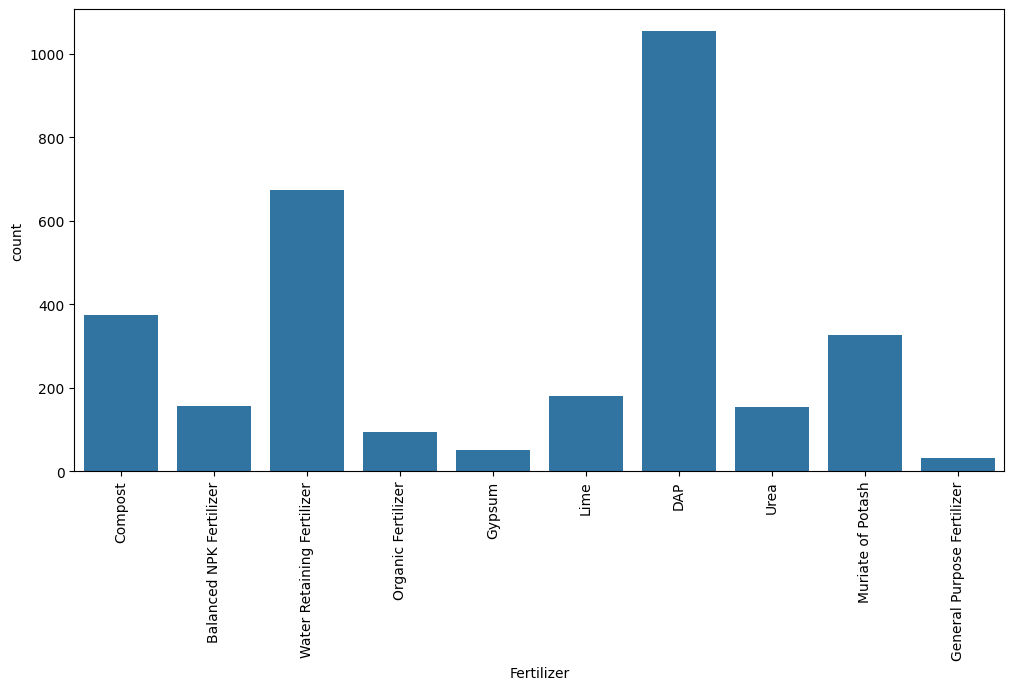

In [82]:
plt.figure(figsize=(12,6))
sns.countplot(x='Fertilizer',data=fertilizer)
plt.xticks(rotation=90)
plt.show()

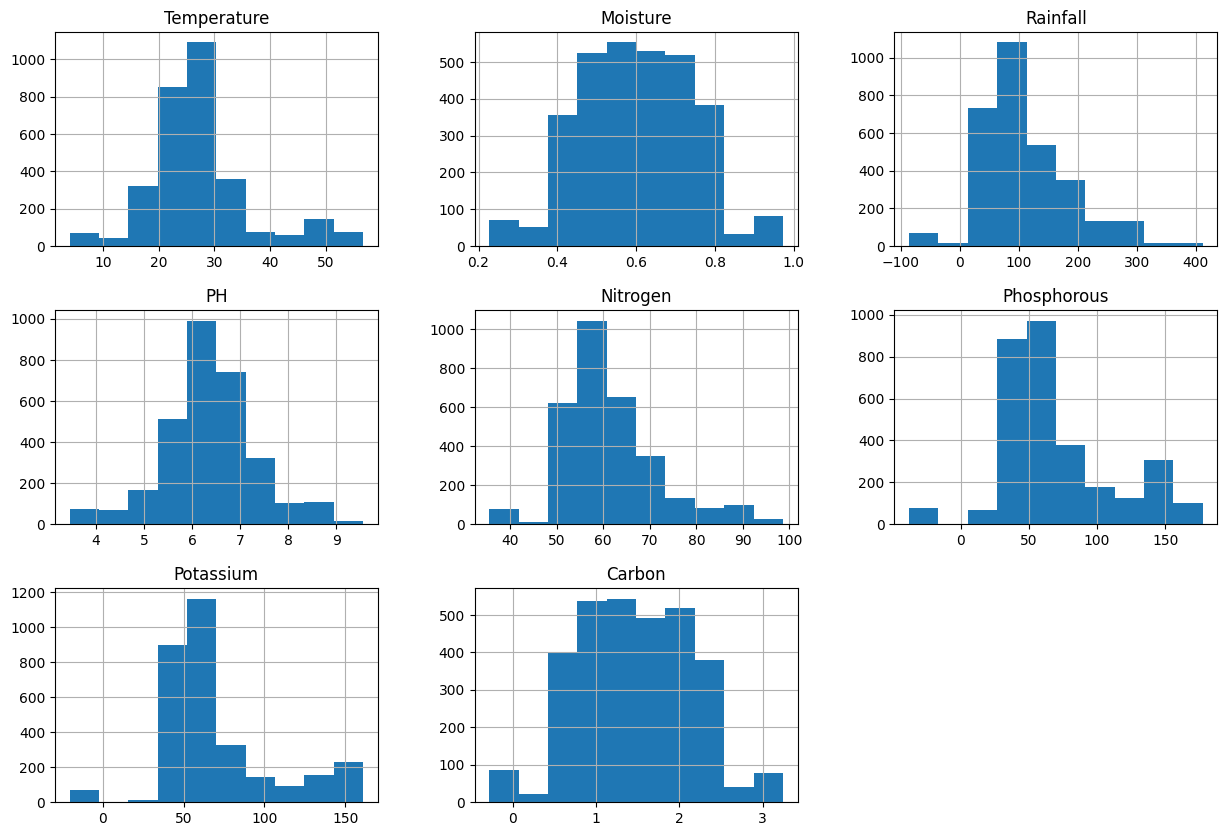

In [83]:
fertilizer.hist(figsize=(15,10))
plt.show()

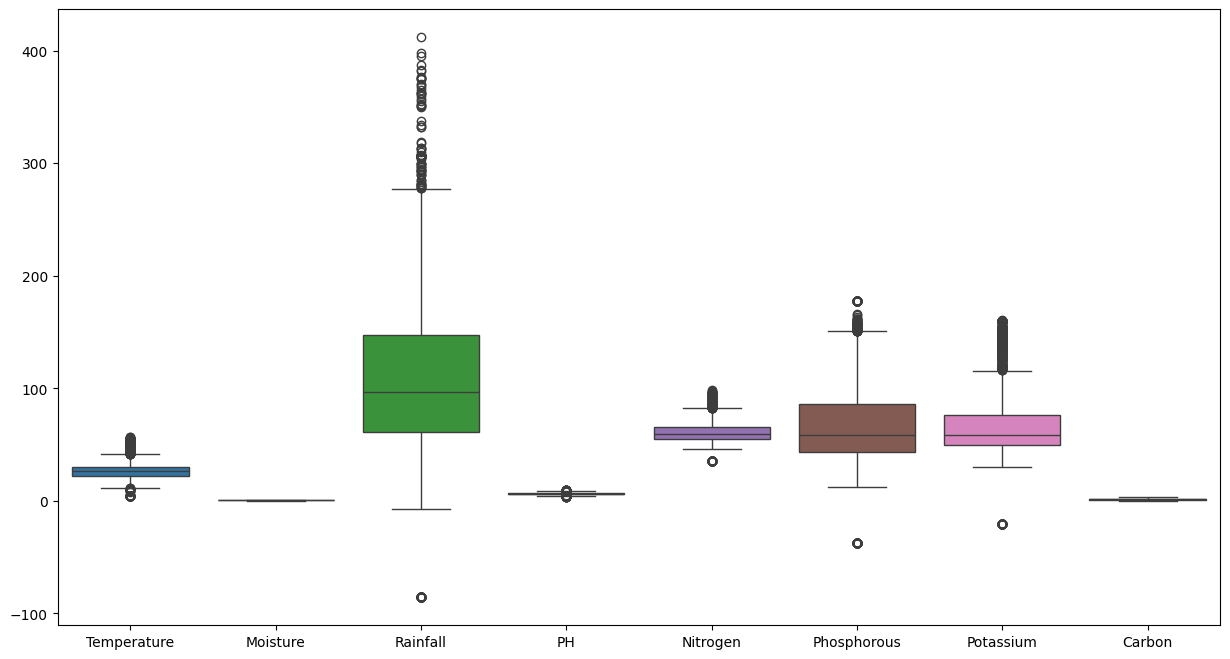

In [84]:
plt.figure(figsize=(15,8))
sns.boxplot(data=fertilizer.drop("Fertilizer",axis=1))
plt.show()

In [85]:
fertilizer.drop("Remark", axis=1, inplace=True)

### Encoding and Scaling

In [86]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
import pickle

encoder = LabelEncoder()
scaler = StandardScaler()


fertilizer["Soil"] = encoder.fit_transform(fertilizer["Soil"])
fertilizer["Crop"] = encoder.fit_transform(fertilizer["Crop"])
fertilizer["Fertilizer"] = encoder.fit_transform(fertilizer["Fertilizer"])

### Feature Selection

In [87]:
X = fertilizer.drop("Fertilizer", axis=1)
Y = fertilizer["Fertilizer"]

In [103]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pickle.dump(scaler,open("../model/fertlizer_scaler.pkl","wb"))


### Model Training

In [89]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

### KNN

In [90]:
model_KNN = KNeighborsClassifier()
model_KNN.fit(X_train,y_train)

train_pred_KNN = model_KNN.predict(X_train)
test_pred_KNN = model_KNN.predict(X_test)

In [91]:
print("train accuracy KNN ",accuracy_score(y_train,train_pred_KNN))
print("test accuracy KNN ",accuracy_score(y_test,test_pred_KNN))

train accuracy KNN  0.7830645161290323
test accuracy KNN  0.6370967741935484


### Decision Tree

In [92]:
model_DT = DecisionTreeClassifier()
model_DT.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [93]:
train_pred_DT = model_DT.predict(X_train)
test_pred_DT = model_DT.predict(X_test)

In [94]:
print("train accuracy DT ",accuracy_score(y_train,train_pred_DT))
print("test accuracy DT ",accuracy_score(y_test,test_pred_DT))

train accuracy DT  1.0
test accuracy DT  0.9919354838709677


### Logistic Regression

In [95]:
model_LR = LogisticRegression()
model_LR.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [96]:
train_pred_LR = model_LR.predict(X_train)
test_pred_LR = model_LR.predict(X_test)

In [97]:
print("train accuracy LR ",accuracy_score(y_train,train_pred_LR))
print("test accuracy LR ",accuracy_score(y_test,test_pred_LR))

train accuracy LR  0.8233870967741935
test accuracy LR  0.785483870967742


### Random Forest

In [98]:
model_RF = RandomForestClassifier(n_estimators=100)
model_RF.fit(X_train,y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [99]:
train_pred_RF = model_RF.predict(X_train)
test_pred_RF = model_RF.predict(X_test)

In [100]:
print("train accuracy RF ",accuracy_score(y_train,train_pred_RF))
print("test accuracy RF ",accuracy_score(y_test,test_pred_RF))

train accuracy RF  1.0
test accuracy RF  0.9870967741935484


In [101]:
from sklearn.metrics import classification_report

print(classification_report(y_test, test_pred_RF ))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       0.98      0.99      0.98        84
           2       0.99      1.00      0.99       206
           3       1.00      1.00      1.00         7
           4       1.00      0.50      0.67         6
           5       0.97      0.97      0.97        39
           6       1.00      1.00      1.00        66
           7       1.00      0.94      0.97        18
           8       1.00      0.97      0.99        34
           9       0.98      0.99      0.99       128

    accuracy                           0.99       620
   macro avg       0.99      0.94      0.96       620
weighted avg       0.99      0.99      0.99       620



In [104]:
model = model_RF
pickle.dump(model,open("../model/fertilizer_model.pkl","wb"))

In [107]:
# Reload original dataset
original_df = pd.read_csv("../Data Set/fertilizer_recommendation_dataset.csv")

# Create encoders
soil_encoder = LabelEncoder()
soil_encoder.fit(original_df["Soil"])

crop_encoder = LabelEncoder()
crop_encoder.fit(original_df["Crop"])

fertilizer_encoder = LabelEncoder()
fertilizer_encoder.fit(original_df["Fertilizer"])


pickle.dump(soil_encoder,open("../model/soil_encoder.pkl","wb"))
pickle.dump(crop_encoder,open("../model/crop_encoder.pkl","wb"))
pickle.dump(fertilizer_encoder,open("../model/fertilizer_encoder.pkl","wb"))
